In [1]:
import numpy as np        # For numerical operations
import pandas as pd       # For data manipulation and analysis
import matplotlib.pyplot as plt  # For data visualization
%matplotlib inline

# Importing WordCloud for text visualization
from wordcloud import WordCloud

# Importing NLTK for natural language processing
import nltk
from nltk.corpus import stopwords    # For stopwords


# Downloading NLTK data
nltk.download('stopwords')   # Downloading stopwords data
nltk.download('punkt')    
nltk.download('punkt_tab') 

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv(
    '/content/drive/MyDrive/Project/dataset/spam.csv',
    encoding='latin1')

In [4]:
df.head(10)

,Body,Label,source
0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1,SpamAssassin
1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,SpamAssassin
2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,SpamAssassin
3,##############################################...,1,SpamAssassin
4,I thought you might like these:\n1) Slim Down ...,1,SpamAssassin
5,A POWERHOUSE GIFTING PROGRAM You Don't Want To...,1,SpamAssassin
6,Help wanted. We are a 14 year old fortune 500...,1,SpamAssassin
7,ReliaQuote - Save Up To 70% On Life Insurance\...,1,SpamAssassin
8,TIRED OF THE BULL OUT THERE?\nWant To Stop Los...,1,SpamAssassin
9,"Dear ricardo1 ,\nCOST EFFECTIVE Direct Email A...",1,SpamAssassin


In [5]:
styled_df = df.head()
styled_df = styled_df.style.set_table_styles([
    {"selector": "th", "props": [("color", 'black'), ("background-color", "#FFFFFF")]}
])
styled_df

,Body,Label,source
0,"Save up to 70% on Life Insurance. Why Spend More Than You Have To?Life Quote Savings Ensuring your family's financial security is very important. Life Quote Savings makes buying life insurance simple and affordable. We Provide FREE Access to The Very Best Companies and The Lowest Rates.Life Quote Savings is FAST, EASY and SAVES you money! Let us help you get started with the best values in the country on new coverage. You can SAVE hundreds or even thousands of dollars by requesting a FREE quote from Lifequote Savings. Our service will take you less than 5 minutes to complete. Shop and compare. SAVE up to 70% on all types of Life insurance! Click Here For Your Free Quote!Protecting your family is the best investment you'll ever make! If you are in receipt of this email in error and/or wish to be removed from our list, PLEASE CLICK HERE AND TYPE REMOVE. If you reside in any state which prohibits e-mail solicitations for insurance, please disregard this email.",1,SpamAssassin
1,"1) Fight The Risk of Cancer! http://www.adclick.ws/p.cfm?o=315&s=pk0072) Slim Down - Guaranteed to lose 10-12 lbs in 30 days http://www.adclick.ws/p.cfm?o=249&s=pk0073) Get the Child Support You Deserve - Free Legal Advice http://www.adclick.ws/p.cfm?o=245&s=pk0024) Join the Web's Fastest Growing Singles Community http://www.adclick.ws/p.cfm?o=259&s=pk0075) Start Your Private Photo Album Online! http://www.adclick.ws/p.cfm?o=283&s=pk007Have a Wonderful Day, Offer Manager PrizeMamaIf you wish to leave this list please use the link below. http://www.qves.com/trim/?ilug@linux.ie%7C17%7C114258 -- Irish Linux Users' Group: ilug@linux.ie http://www.linux.ie/mailman/listinfo/ilug for (un)subscription information. List maintainer: listmaster@linux.ie",1,SpamAssassin
2,"1) Fight The Risk of Cancer! http://www.adclick.ws/p.cfm?o=315&s=pk0072) Slim Down - Guaranteed to lose 10-12 lbs in 30 days http://www.adclick.ws/p.cfm?o=249&s=pk0073) Get the Child Support You Deserve - Free Legal Advice http://www.adclick.ws/p.cfm?o=245&s=pk0024) Join the Web's Fastest Growing Singles Community http://www.adclick.ws/p.cfm?o=259&s=pk0075) Start Your Private Photo Album Online! http://www.adclick.ws/p.cfm?o=283&s=pk007Have a Wonderful Day, Offer Manager PrizeMamaIf you wish to leave this list please use the link below. http://www.qves.com/trim/?zzzz@spamassassin.taint.org%7C17%7C308417",1,SpamAssassin
3,"################################################## # # # Adult Club # # Offers FREE Membership # # # ##################################################>>>>> INSTANT ACCESS TO ALL SITES NOW >>>>> Your User Name And Password is. >>>>> User Name: zzzz@spamassassin.taint.org >>>>> Password: 7603825 of the Best Adult Sites on the Internet for FREE! --------------------------------------- NEWS 08/18/02 With just over 2.9 Million Members that signed up for FREE, Last month there were 721,184 New Members. Are you one of them yet??? --------------------------------------- Our Membership FAQQ. Why are you offering free access to 5 adult membership sites for free? A. I have advertisers that pay me for ad space so you don't have to pay for membership.Q. Is it true my membership is for life? A. Absolutely you'll never have to pay a cent the advertisers do.Q. Can I give my account to my friends and family? A. Yes, as long they are over the age of 18.Q. Do I have to sign up for all 5 membership sites? A. No just one to get access to all of them.Q. How do I get started? A. Click on one of the following links below to become a member.- These are multi million dollar operations with policies and rules. - Fill in the required info and they won't charge you for the Free pass! - If you don't believe us, just read their terms and conditions.---------------------------# 5. > Adults Farm http://80.71.66.8/farm/?aid=760382 Girls and Animals Getting Freaky....FREE Lifetime Membership!!# 4. > Sexy Celebes http://80.71.66.8/celebst/?aid=760382 Thousands Of XXX Celebes doing it...FREE Li

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17570 entries, 0 to 17569
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Body    17570 non-null  object
 1   Label   17570 non-null  int64 
 2   source  17570 non-null  object
dtypes: int64(1), object(2)
memory usage: 411.9+ KB


In [7]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['Label'])

In [8]:
df.drop('Label', axis=1, inplace=True)

In [9]:
styled_df = df.head().style


# Modify the color and background color of the table headers (th)
styled_df.set_table_styles([
    {"selector": "th", "props": [("color", 'Black'), ("background-color", "#FFFFFF"), ('font-weight', 'bold')]}
])


,Body,source,target
0,"Save up to 70% on Life Insurance. Why Spend More Than You Have To?Life Quote Savings Ensuring your family's financial security is very important. Life Quote Savings makes buying life insurance simple and affordable. We Provide FREE Access to The Very Best Companies and The Lowest Rates.Life Quote Savings is FAST, EASY and SAVES you money! Let us help you get started with the best values in the country on new coverage. You can SAVE hundreds or even thousands of dollars by requesting a FREE quote from Lifequote Savings. Our service will take you less than 5 minutes to complete. Shop and compare. SAVE up to 70% on all types of Life insurance! Click Here For Your Free Quote!Protecting your family is the best investment you'll ever make! If you are in receipt of this email in error and/or wish to be removed from our list, PLEASE CLICK HERE AND TYPE REMOVE. If you reside in any state which prohibits e-mail solicitations for insurance, please disregard this email.",SpamAssassin,1
1,"1) Fight The Risk of Cancer! http://www.adclick.ws/p.cfm?o=315&s=pk0072) Slim Down - Guaranteed to lose 10-12 lbs in 30 days http://www.adclick.ws/p.cfm?o=249&s=pk0073) Get the Child Support You Deserve - Free Legal Advice http://www.adclick.ws/p.cfm?o=245&s=pk0024) Join the Web's Fastest Growing Singles Community http://www.adclick.ws/p.cfm?o=259&s=pk0075) Start Your Private Photo Album Online! http://www.adclick.ws/p.cfm?o=283&s=pk007Have a Wonderful Day, Offer Manager PrizeMamaIf you wish to leave this list please use the link below. http://www.qves.com/trim/?ilug@linux.ie%7C17%7C114258 -- Irish Linux Users' Group: ilug@linux.ie http://www.linux.ie/mailman/listinfo/ilug for (un)subscription information. List maintainer: listmaster@linux.ie",SpamAssassin,1
2,"1) Fight The Risk of Cancer! http://www.adclick.ws/p.cfm?o=315&s=pk0072) Slim Down - Guaranteed to lose 10-12 lbs in 30 days http://www.adclick.ws/p.cfm?o=249&s=pk0073) Get the Child Support You Deserve - Free Legal Advice http://www.adclick.ws/p.cfm?o=245&s=pk0024) Join the Web's Fastest Growing Singles Community http://www.adclick.ws/p.cfm?o=259&s=pk0075) Start Your Private Photo Album Online! http://www.adclick.ws/p.cfm?o=283&s=pk007Have a Wonderful Day, Offer Manager PrizeMamaIf you wish to leave this list please use the link below. http://www.qves.com/trim/?zzzz@spamassassin.taint.org%7C17%7C308417",SpamAssassin,1
3,"################################################## # # # Adult Club # # Offers FREE Membership # # # ##################################################>>>>> INSTANT ACCESS TO ALL SITES NOW >>>>> Your User Name And Password is. >>>>> User Name: zzzz@spamassassin.taint.org >>>>> Password: 7603825 of the Best Adult Sites on the Internet for FREE! --------------------------------------- NEWS 08/18/02 With just over 2.9 Million Members that signed up for FREE, Last month there were 721,184 New Members. Are you one of them yet??? --------------------------------------- Our Membership FAQQ. Why are you offering free access to 5 adult membership sites for free? A. I have advertisers that pay me for ad space so you don't have to pay for membership.Q. Is it true my membership is for life? A. Absolutely you'll never have to pay a cent the advertisers do.Q. Can I give my account to my friends and family? A. Yes, as long they are over the age of 18.Q. Do I have to sign up for all 5 membership sites? A. No just one to get access to all of them.Q. How do I get started? A. Click on one of the following links below to become a member.- These are multi million dollar operations with policies and rules. - Fill in the required info and they won't charge you for the Free pass! - If you don't believe us, just read their terms and conditions.---------------------------# 5. > Adults Farm http://80.71.66.8/farm/?aid=760382 Girls and Animals Getting Freaky....FREE Lifetime Membership!!# 4. > Sexy Celebes http://80.71.66.8/celebst/?aid=760382 Thousands Of XXX Celebes doing it...FREE L

In [10]:
df.isnull().sum()

,0
Body,0
source,0
target,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(17570, 3)

<div style="
    background-color:#2C3E50;
    padding:12px;
    text-align:center;
    color:white;
    font-size:24px;
    font-weight:bold;
    border-radius:8px;
">
    Exploratory Data Analysis
</div>

In [13]:
values = df['target'].value_counts()
total = values.sum()

percentage_0 = (values[0] /total) * 100
percentage_1 = (values[1]/ total) *100

print('percentage of 0 :' ,percentage_0)
print('percentage of 1 :' ,percentage_1)

percentage of 0 : 62.65793966989186
percentage of 1 : 37.34206033010814


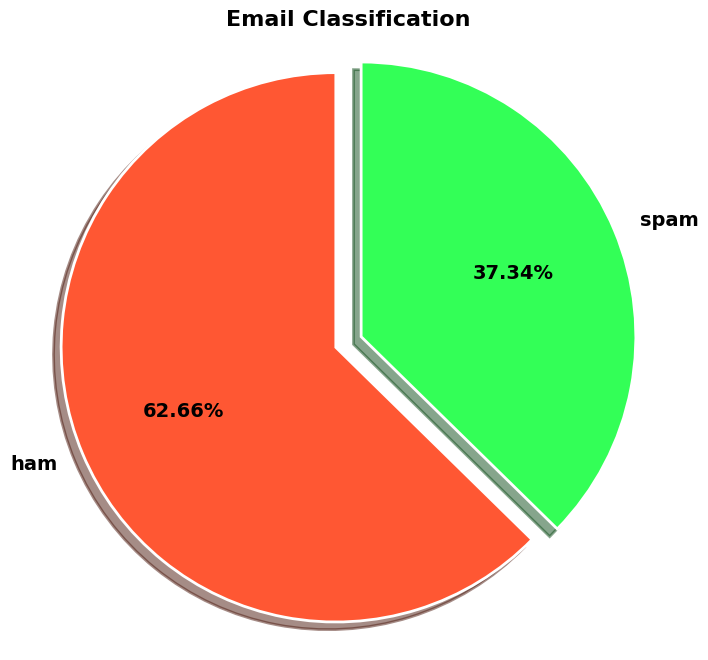

In [14]:
import matplotlib.pyplot as plt

# Sample data
# values = [75, 25]  # Example values for 'ham' and 'spam'

# Define custom colors
colors = ['#FF5733', '#33FF57']

# Define the explode parameter to create a gap between slices
explode = (0, 0.1)  # Explode the second slice (spam) by 10%

# Create a figure with a white background
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor('white')

# Create the pie chart with custom colors, labels, explode parameter, and shadow
wedges, texts, autotexts = ax.pie(
    values, labels=['ham', 'spam'],
    autopct='%0.2f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    explode=explode,  # Apply the explode parameter
    shadow=True  # Add shadow
)

# Customize text properties
for text, autotext in zip(texts, autotexts):
    text.set(size=14, weight='bold')
    autotext.set(size=14, weight='bold')

# Add a title
ax.set_title('Email Classification', fontsize=16, fontweight='bold')

# Equal aspect ratio ensures that pie is drawn as a circle
ax.axis('equal')

# Show the pie chart
plt.show()


In [15]:
df['num_characters'] = df['Body'].apply(len)
df['num_words'] = df['Body'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentence'] = df['Body'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [16]:
df[['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,1.757000e+04,1.757000e+04,17570.000000
mean,2.901563e+03,5.878300e+02,33.434206
std,1.289594e+05,2.734530e+04,1684.946316
min,1.000000e+00,0.000000e+00,0.000000
25%,4.490000e+02,9.000000e+01,5.000000
50%,9.355000e+02,1.890000e+02,10.000000
75%,1.985750e+03,3.960000e+02,19.000000
max,1.708563e+07,3.623500e+06,223247.000000


In [17]:
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,1.100900e+04,1.100900e+04,11009.000000
mean,3.582807e+03,7.348364e+02,40.840312
std,1.628912e+05,3.454201e+04,2128.203988
min,1.700000e+01,3.000000e+00,1.000000
25%,4.810000e+02,9.700000e+01,5.000000
50%,1.036000e+03,2.120000e+02,9.000000
75%,2.086000e+03,4.230000e+02,19.000000
max,1.708563e+07,3.623500e+06,223247.000000


In [18]:
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,6561.000000,6561.000000,6561.000000
mean,1758.473708,341.161256,21.007164
std,3636.862682,635.569505,54.577312
min,1.000000,0.000000,0.000000
25%,417.000000,83.000000,6.000000
50%,789.000000,159.000000,10.000000
75%,1722.000000,332.000000,20.000000
max,144611.000000,13294.000000,3093.000000


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


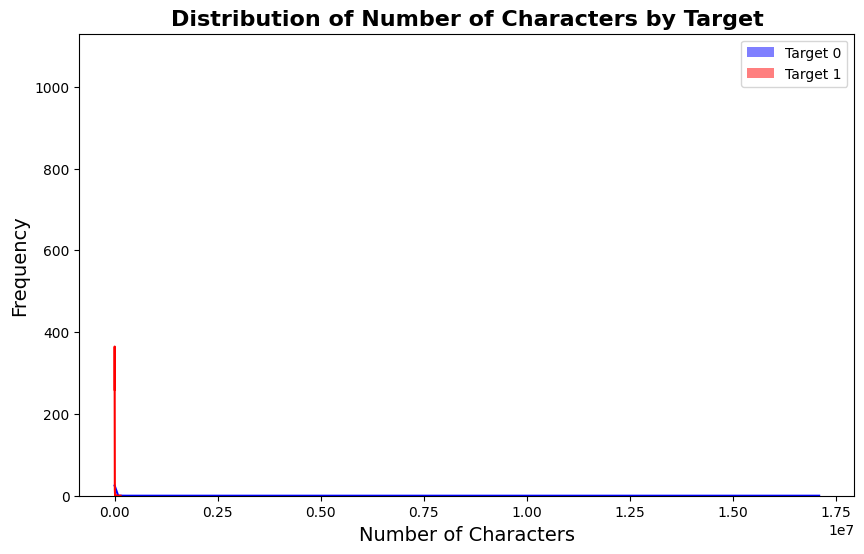

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure and set the figure size
plt.figure(figsize=(10, 6))

# Plot the histogram for target 0 in blue
sns.histplot(df[df['target'] == 0]['num_characters'], color='blue', label='Target 0', kde=True)

# Plot the histogram for target 1 in red
sns.histplot(df[df['target'] == 1]['num_characters'], color='red', label='Target 1', kde=True)

# Add labels and a title
plt.xlabel('Number of Characters', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Number of Characters by Target', fontsize=16, fontweight='bold')

# Add a legend
plt.legend()

# Customize the appearance of the plot
sns.set(style='whitegrid')  # Add a white grid background

# Show the plot
plt.show()

In [20]:
df['num_characters'].sort_values(ascending=False).head(10)

,num_characters
17569,17085626
5280,195963
345,144611
12599,121502
5073,107989
10636,104553
10878,93686
11936,91399
10262,88311
5013,87974


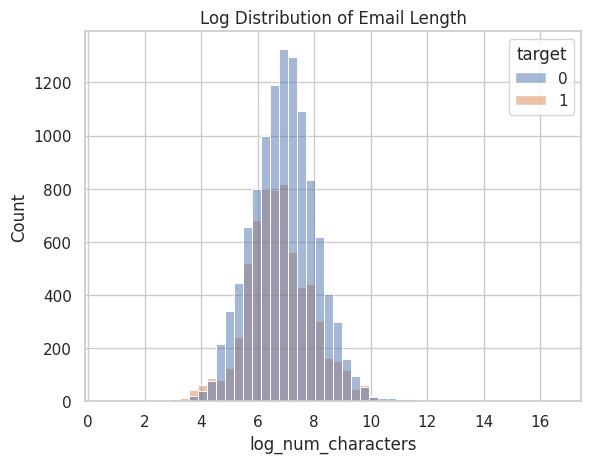

In [21]:
import numpy as np

df['log_num_characters'] = np.log1p(df['num_characters'])

sns.histplot(
    data=df,
    x='log_num_characters',
    hue='target',
    bins=50
)
plt.title('Log Distribution of Email Length')
plt.show()

In [22]:
df.groupby('target')['num_characters'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,11009.0,3582.807158,162891.228042,17.0,481.0,1036.0,2086.0,17085626.0
1,6561.0,1758.473708,3636.862682,1.0,417.0,789.0,1722.0,144611.0


In [23]:
from scipy.stats import mannwhitneyu

spam = df[df['target']==1]['num_characters']
ham = df[df['target']==0]['num_characters']

stat, p = mannwhitneyu(spam, ham)

print(f"P-value: {p}")

P-value: 6.363634308272389e-28


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


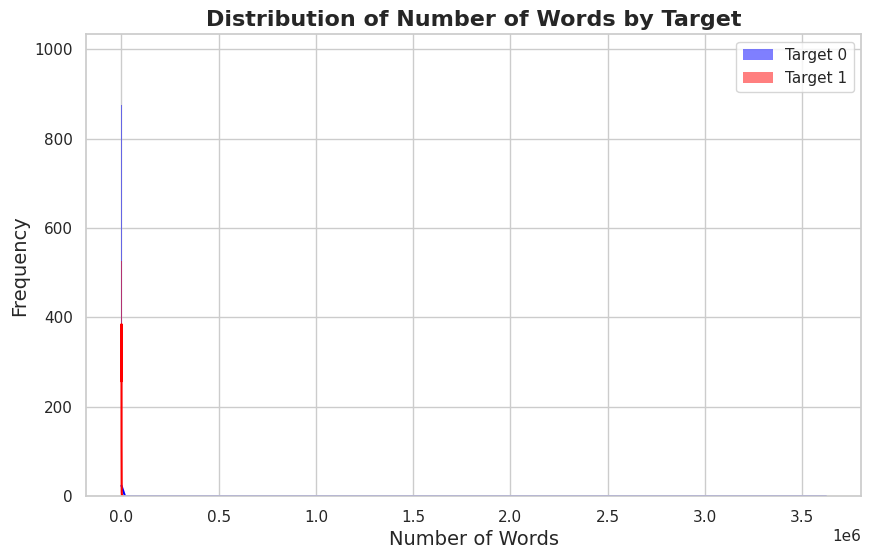

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure and set the figure size
plt.figure(figsize=(10, 6))

# Plot the histogram for target 0 in blue
sns.histplot(df[df['target'] == 0]['num_words'], color='blue', label='Target 0', kde=True)

# Plot the histogram for target 1 in red
sns.histplot(df[df['target'] == 1]['num_words'], color='red', label='Target 1', kde=True)

# Add labels and a title
plt.xlabel('Number of Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Number of Words by Target', fontsize=16, fontweight='bold')

# Add a legend
plt.legend()

# Customize the appearance of the plot
sns.set(style='whitegrid')  # Add a white grid background

# Show the plot
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


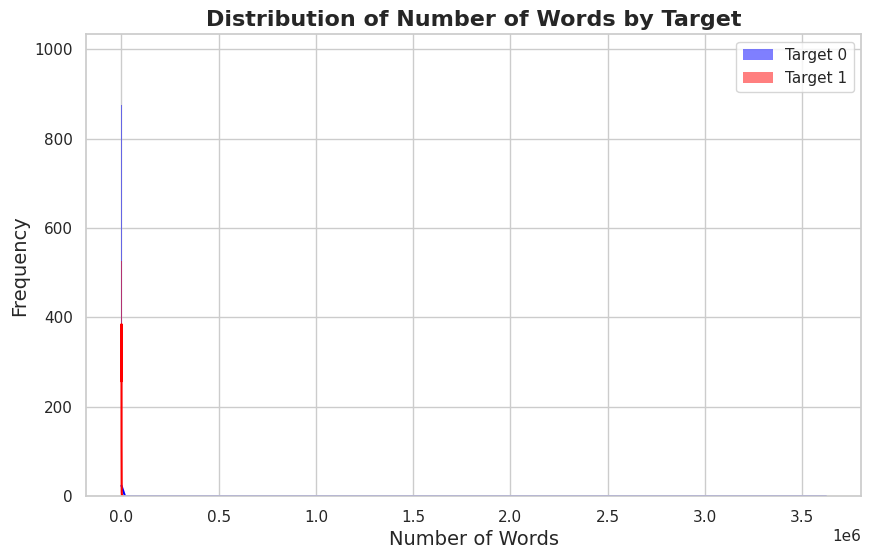

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure and set the figure size
plt.figure(figsize=(10, 6))

# Plot the histogram for target 0 in blue
sns.histplot(df[df['target'] == 0]['num_words'], color='blue', label='Target 0', kde=True)

# Plot the histogram for target 1 in red
sns.histplot(df[df['target'] == 1]['num_words'], color='red', label='Target 1', kde=True)

# Add labels and a title
plt.xlabel('Number of Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Distribution of Number of Words by Target', fontsize=16, fontweight='bold')

# Add a legend
plt.legend()

# Customize the appearance of the plot
sns.set(style='whitegrid')  # Add a white grid background

# Show the plot
plt.show()


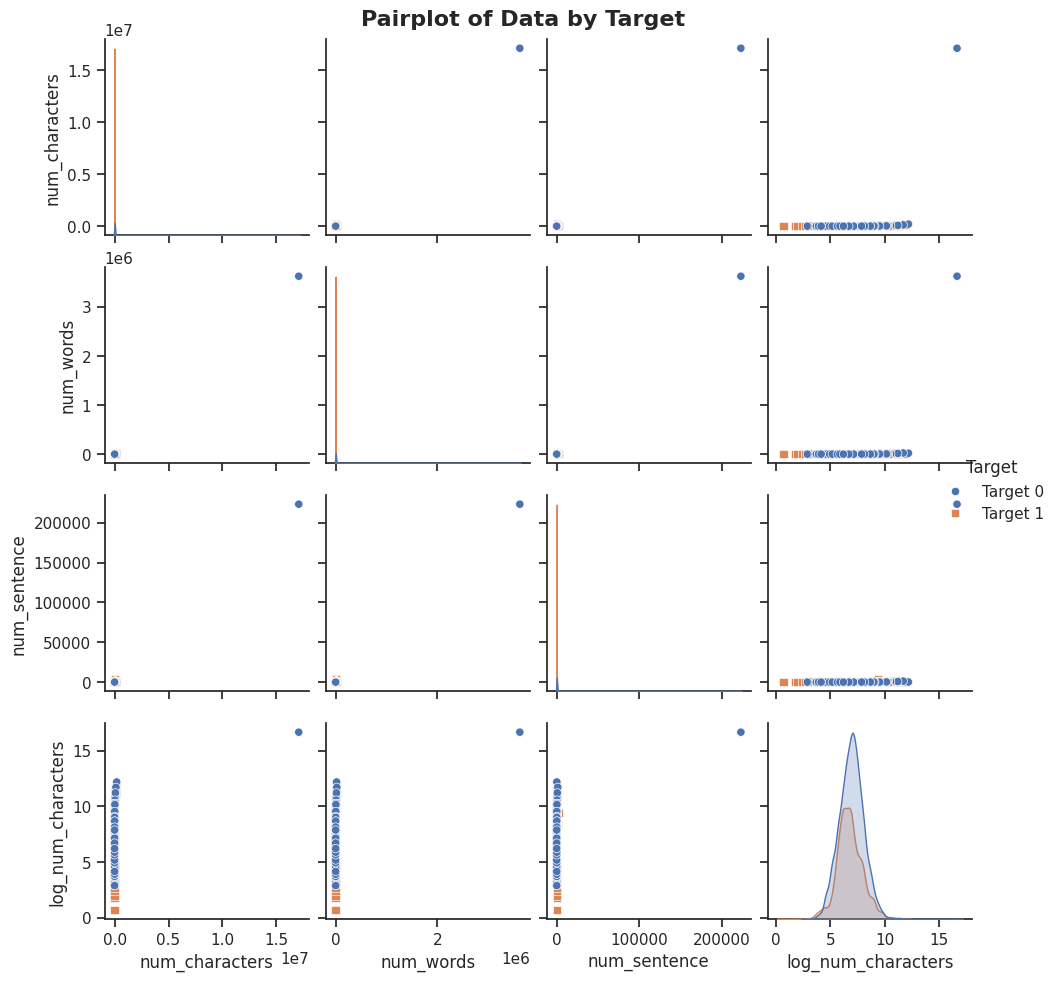

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot with custom styling
sns.set(style='ticks', color_codes=True)
g = sns.pairplot(df, hue='target', diag_kind='kde', markers=["o", "s"])

# Set a title for the pairplot
g.fig.suptitle("Pairplot of Data by Target", fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.95)  # Adjust the position of the title

# Customize the legend
g._legend.set_title('Target')
for t, l in zip(g._legend.texts, ["Target 0", "Target 1"]):
    t.set_text(l)

# Show the pairplot
plt.show()


In [27]:
df[['target','num_characters', 'num_words', 'num_sentence']].corr()

,target,num_characters,num_words,num_sentence
target,1.000000,-0.006843,-0.006964,-0.005694
num_characters,-0.006843,1.000000,0.999931,0.999630
num_words,-0.006964,0.999931,1.000000,0.999773
num_sentence,-0.005694,0.999630,0.999773,1.000000


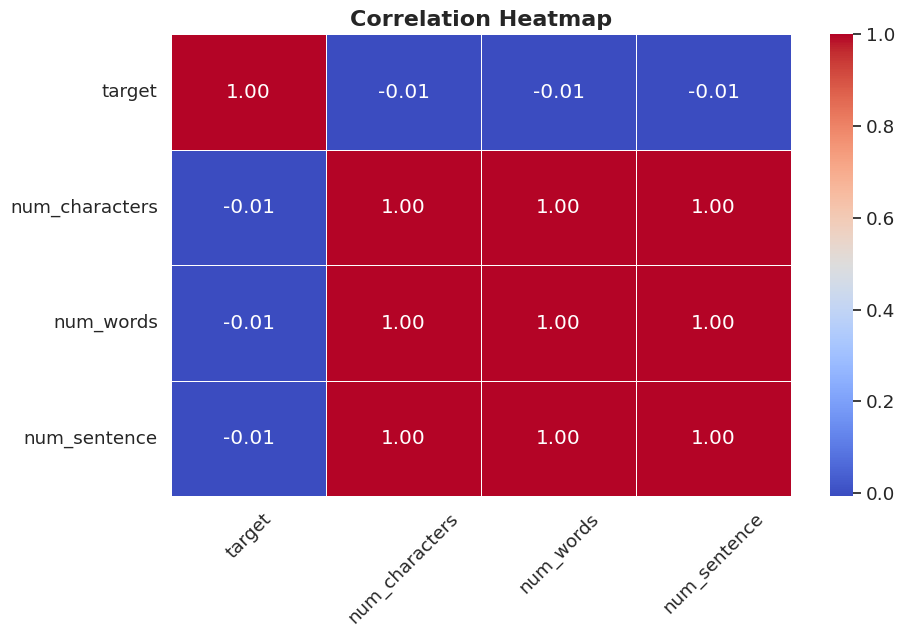

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the columns for the correlation matrix
correlation_matrix = df[['target', 'num_characters', 'num_words', 'num_sentence']].corr()

# Create a heatmap with custom styling
plt.figure(figsize=(10, 6))
sns.set(font_scale=1.2)  # Adjust font scale for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")

# Set a title for the heatmap
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the heatmap
plt.show()


<div style="
    background-color:#2C3E50;
    padding:12px;
    text-align:center;
    color:white;
    font-size:24px;
    font-weight:bold;
    border-radius:8px;
">
    Data Preprocessing
</div>

In [29]:
# Importing the Porter Stemmer for text stemming
from nltk.stem.porter import PorterStemmer

# Importing the string module for handling special characters
import string

# Creating an instance of the Porter Stemmer
ps = PorterStemmer()

# Lowercase transformation and text preprocessing function
def transform_text(text):
    # Transform the text to lowercase
    text = text.lower()
    
    # Tokenization using NLTK
    text = nltk.word_tokenize(text)
    
    # Removing special characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            
    # Removing stop words and punctuation
    text = y[:]
    y.clear()
    
    # Loop through the tokens and remove stopwords and punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
        
    # Stemming using Porter Stemmer
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    
    # Join the processed tokens back into a single string
    return " ".join(y)


In [30]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [32]:
df['transformed_text'] = df['Body'].apply(transform_text)

In [33]:
styled_df = df.head(5).style


# Modify the color and background color of the table headers (th)
styled_df.set_table_styles([
    {"selector": "th", "props": [("color", 'Black'), ("background-color", "#FFFFFF"), ('font-weight', 'bold')]}
])


,Body,source,target,num_characters,num_words,num_sentence,log_num_characters,transformed_text
0,"Save up to 70% on Life Insurance. Why Spend More Than You Have To?Life Quote Savings Ensuring your family's financial security is very important. Life Quote Savings makes buying life insurance simple and affordable. We Provide FREE Access to The Very Best Companies and The Lowest Rates.Life Quote Savings is FAST, EASY and SAVES you money! Let us help you get started with the best values in the country on new coverage. You can SAVE hundreds or even thousands of dollars by requesting a FREE quote from Lifequote Savings. Our service will take you less than 5 minutes to complete. Shop and compare. SAVE up to 70% on all types of Life insurance! Click Here For Your Free Quote!Protecting your family is the best investment you'll ever make! If you are in receipt of this email in error and/or wish to be removed from our list, PLEASE CLICK HERE AND TYPE REMOVE. If you reside in any state which prohibits e-mail solicitations for insurance, please disregard this email.",SpamAssassin,1,1111,191,12,7.013915,save 70 life insur spend life quot save ensur famili financi secur import life quot save make buy life insur simpl afford provid free access best compani lowest quot save fast easi save money let us help get start best valu countri new coverag save hundr even thousand dollar request free quot lifequot save servic take less 5 minut complet shop compar save 70 type life insur click free quot protect famili best invest ever make receipt email error wish remov list pleas click type remov resid state prohibit solicit insur pleas disregard email
1,"1) Fight The Risk of Cancer! http://www.adclick.ws/p.cfm?o=315&s=pk0072) Slim Down - Guaranteed to lose 10-12 lbs in 30 days http://www.adclick.ws/p.cfm?o=249&s=pk0073) Get the Child Support You Deserve - Free Legal Advice http://www.adclick.ws/p.cfm?o=245&s=pk0024) Join the Web's Fastest Growing Singles Community http://www.adclick.ws/p.cfm?o=259&s=pk0075) Start Your Private Photo Album Online! http://www.adclick.ws/p.cfm?o=283&s=pk007Have a Wonderful Day, Offer Manager PrizeMamaIf you wish to leave this list please use the link below. http://www.qves.com/trim/?ilug@linux.ie%7C17%7C114258 -- Irish Linux Users' Group: ilug@linux.ie http://www.linux.ie/mailman/listinfo/ilug for (un)subscription information. List maintainer: listmaster@linux.ie",SpamAssassin,1,753,139,5,6.625392,1 fight risk cancer http slim guarante lose lb 30 day http get child support deserv free legal advic http join web fastest grow singl commun http start privat photo album onlin http wonder day offer manag prizemamaif wish leav list pleas use link http ilug 7c17 7c114258 irish linux user group ilug http un subscript inform list maintain listmast
2,"1) Fight The Risk of Cancer! http://www.adclick.ws/p.cfm?o=315&s=pk0072) Slim Down - Guaranteed to lose 10-12 lbs in 30 days http://www.adclick.ws/p.cfm?o=249&s=pk0073) Get the Child Support You Deserve - Free Legal Advice http://www.adclick.ws/p.cfm?o=245&s=pk0024) Join the Web's Fastest Growing Singles Community http://www.adclick.ws/p.cfm?o=259&s=pk0075) Start Your Private Photo Album Online! http://www.adclick.ws/p.cfm?o=283&s=pk007Have a Wonderful Day, Offer Manager PrizeMamaIf you wish to leave this list please use the link below. http://www.qves.com/trim/?zzzz@spamassassin.taint.org%7C17%7C308417",SpamAssassin,1,610,113,4,6.415097,1 fight risk cancer http slim guarante lose lb 30 day http get child support deserv free legal advic http join web fastest grow singl commun http start privat photo album onlin http wonder day offer manag prizemamaif wish leav list pleas use link http zzzz 7c17 7c308417
3,"################################################## # # # Adult Club # # Offers FREE Membership # # # ##################################################>>>>> INSTANT ACCESS TO ALL SITES NOW >>>>> Your User Name And Password is. >>>>> User Name: zzzz@spamassassin.taint.org >>>>> Password:

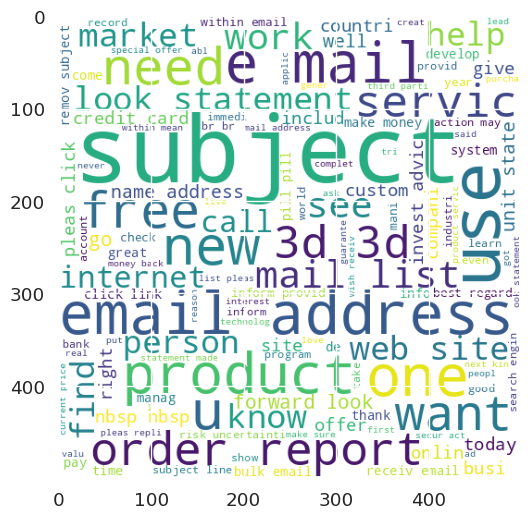

In [34]:
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = 'white')
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(spam_wc)
plt.show()

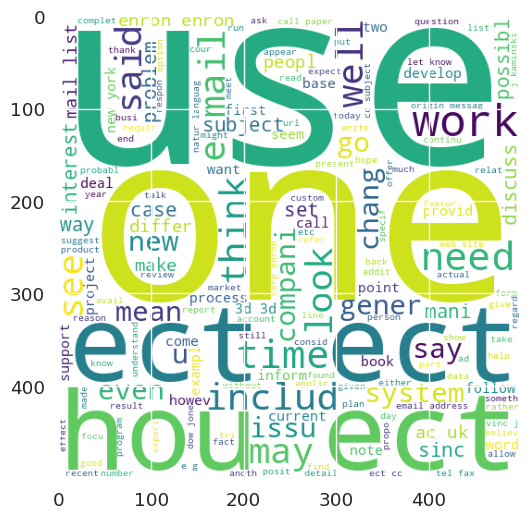

In [35]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize = (15,6))
plt.imshow(ham_wc)
plt.show()

In [36]:
spam_carpos = []
for sentence in df[df['target'] == 1]['transformed_text'].tolist():
    for word in sentence.split():
        spam_carpos.append(word)

In [37]:
from collections import Counter
filter_df = pd.DataFrame(Counter(spam_carpos).most_common(30))

/tmp/ipykernel_11952/2512895475.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = filter_df, x = filter_df[0], y = filter_df[1], palette = 'bright')


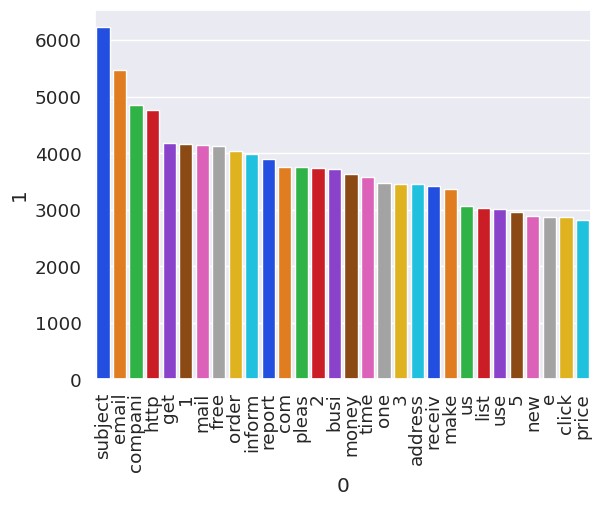

In [38]:
sns.barplot(data = filter_df, x = filter_df[0], y = filter_df[1], palette = 'bright')
plt.xticks(rotation = 90)
plt.show()

In [39]:
ham_carpos = []
for sentence in df[df['target'] == 0]['transformed_text'].tolist():
    for word in sentence.split():
        ham_carpos.append(word)

In [40]:
filter_ham_df = pd.DataFrame(Counter(spam_carpos).most_common(30))

/tmp/ipykernel_11952/699915630.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = filter_ham_df, x = filter_ham_df[0], y = filter_ham_df[1], palette = 'cool')


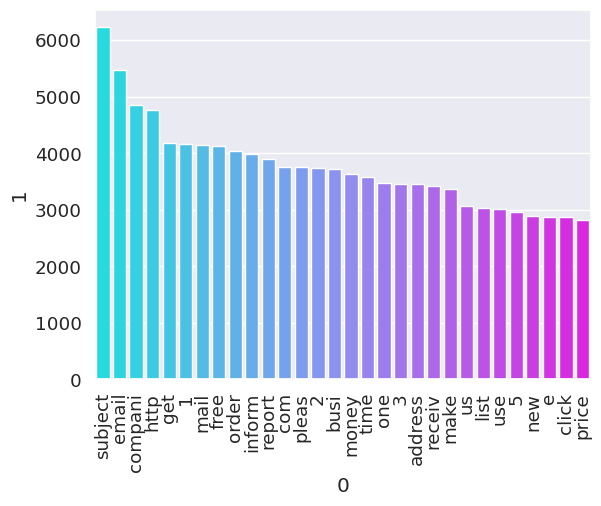

In [41]:
sns.barplot(data = filter_ham_df, x = filter_ham_df[0], y = filter_ham_df[1], palette = 'cool')
plt.xticks(rotation = 90)
plt.show()

<div style="
    background-color:#2C3E50;
    padding:12px;
    text-align:center;
    color:white;
    font-size:24px;
    font-weight:bold;
    border-radius:8px;
">
    Model Building
</div>

In [43]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfid = TfidfVectorizer(max_features = 3000)

In [44]:
X = tfid.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size = 0.20, random_state = 2)

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [47]:
svc = SVC(kernel= "sigmoid", gamma  = 1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver = 'liblinear', penalty = 'l1')
rfc = RandomForestClassifier(n_estimators = 50, random_state = 2 )
abc = AdaBoostClassifier(n_estimators = 50, random_state = 2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
gbdt = GradientBoostingClassifier(n_estimators = 50, random_state = 2)    
xgb  = XGBClassifier(n_estimators = 50, random_state = 2)


    

In [51]:
clfs = {
    'SVC': svc,
    'KNN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'Adaboost': abc,
    'Bgc': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
    
}

In [52]:
from sklearn.metrics import accuracy_score, precision_score
def train_classifier(clfs, X_train, y_train, X_test, y_test):
    clfs.fit(X_train,y_train)
    y_pred = clfs.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy , precision

In [ ]:
accuracy_scores = []
precision_scores = []
for name , clfs in clfs.items():
    current_accuracy, current_precision = train_classifier(clfs, X_train, y_train, X_test, y_test)
    print()
    print("For: ", name)
    print("Accuracy: ", current_accuracy)
    print("Precision: ", current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    